In [222]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy.stats import spearmanr, pearsonr,chi2_contingency

In [223]:
df = pd.read_csv("insurance_claims_clean.csv", index_col="policy_number")
df.columns

Index(['age', 'policy_bind_date', 'policy_state', 'policy_csl',
       'policy_deductable', 'policy_annual_premium', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'capital_gains', 'capital_loss', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'property_damage', 'bodily_injuries', 'witnesses',
       'police_report_available', 'total_claim_amount', 'injury_claim',
       'property_claim', 'vehicle_claim', 'auto_make', 'auto_model',
       'auto_year', 'insured_zip_class', 'policy_bind_year',
       'policy_bind_month', 'policy_bind_weekday', 'policy_bind_week',
       'incident_year', 'incident_month', 'incident_weekday', 'incident_week',
       'policy_duration_days', 'policy_duration_months', 'age_of_auto',
       'capital_total', 'fra

In [224]:
df.nunique().T

age                              46
policy_bind_date                951
policy_state                      3
policy_csl                        3
policy_deductable                 3
policy_annual_premium           991
insured_education_level           7
insured_occupation               14
insured_hobbies                  20
insured_relationship              6
capital_gains                   338
capital_loss                    354
incident_date                    60
incident_type                     4
collision_type                    4
incident_severity                 4
authorities_contacted             4
incident_state                    7
incident_city                     7
incident_location              1000
incident_hour_of_the_day         24
number_of_vehicles_involved       4
property_damage                   3
bodily_injuries                   3
witnesses                         4
police_report_available           3
total_claim_amount              763
injury_claim                

In [225]:
col_quan = df.select_dtypes(include=['float64', 'int64']).columns


# Data Viz / Statistical tests on quantitative features

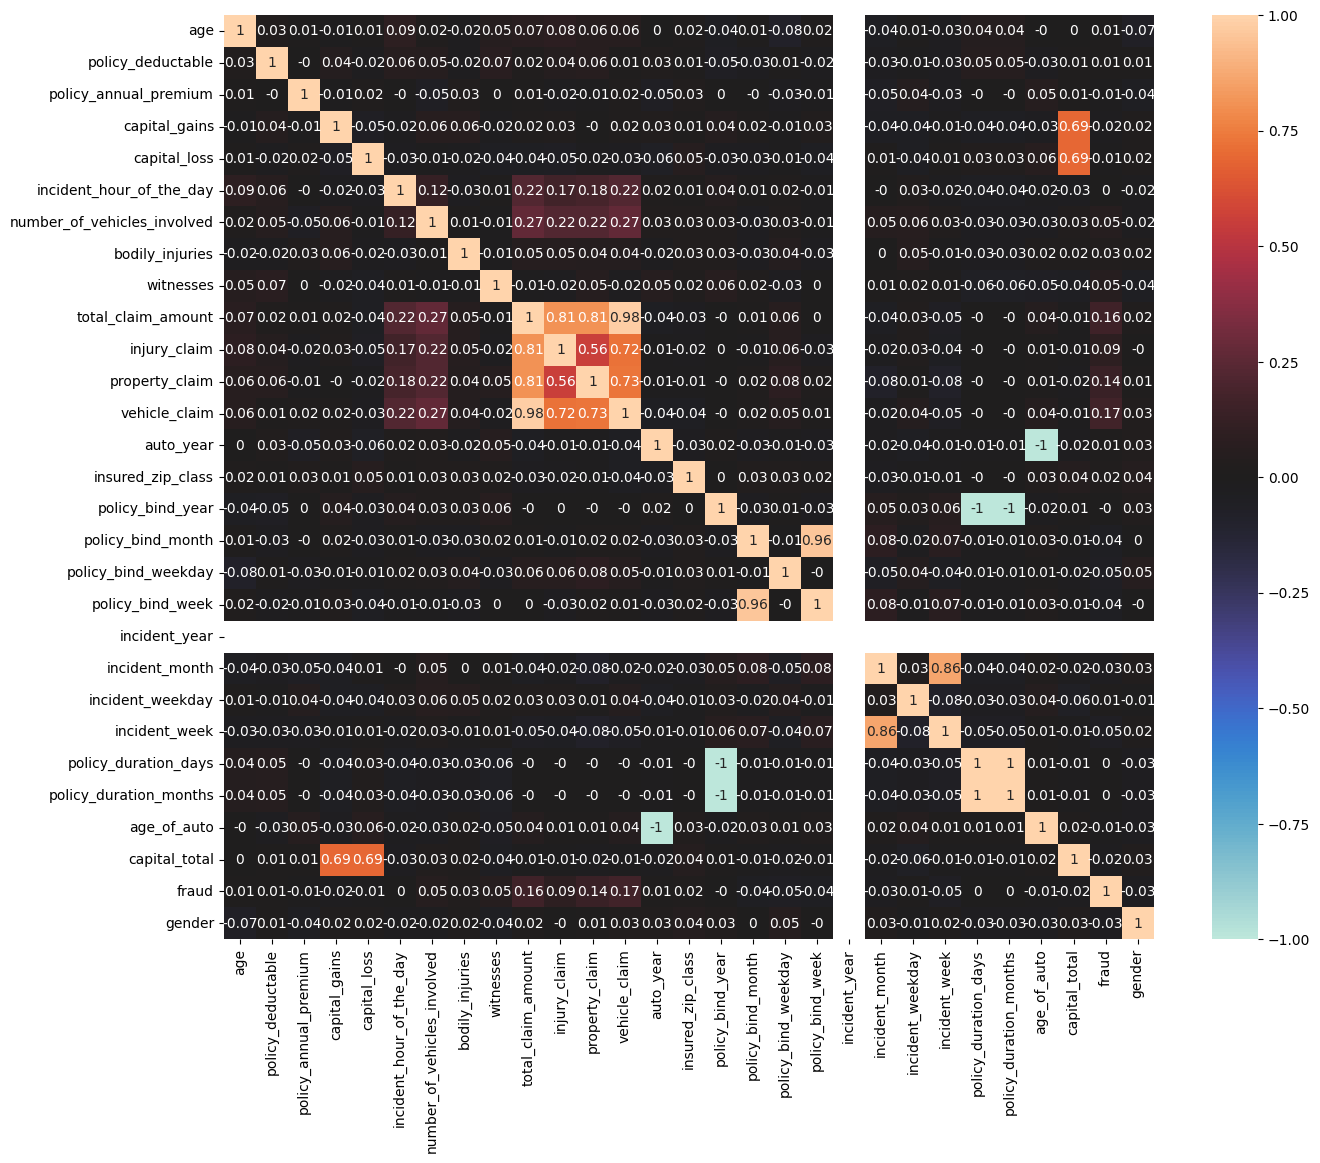

In [226]:
#heatmap to check correlation
plt.figure(figsize = (15,12))
sns.heatmap(np.round(df[col_quan].corr(),2), annot=True, center =0);

Assumption Total claim is sum of all claims is:  True


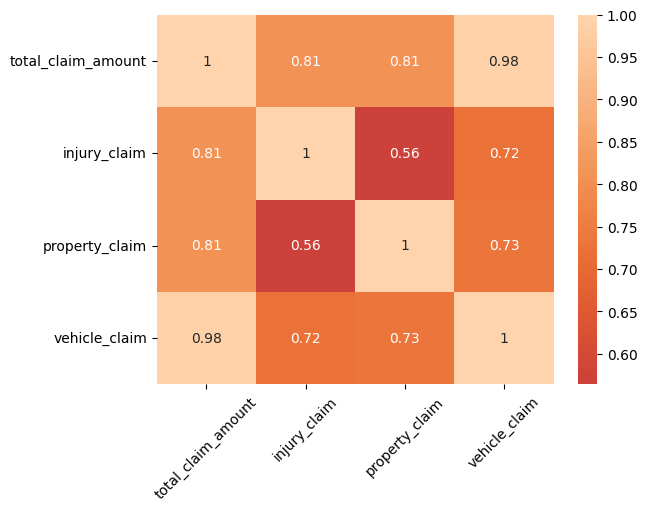

In [227]:
#check features: 'total_claim_amount', "injury_claim", 'property_claim','vehicle_claim'
claim=['total_claim_amount', "injury_claim", 'property_claim','vehicle_claim']
sns.heatmap(np.round(df[claim].corr(),3),annot=True,center=0)
plt.xticks(rotation=45);

print("Assumption Total claim is sum of all claims is: ", (df['total_claim_amount']-(df['injury_claim']+df['vehicle_claim']+df['property_claim'])).sum()==0)

In [228]:

col_quan=col_quan.drop(["total_claim_amount"])
col_qual = df.drop(col_quan,axis=1).columns

## Statistical tests Pearson / Spearman

In [229]:
#run Pearson Test for linear relation
dic_pearson ={}
dic_spearman ={}

for col in col_quan:
    X=df[col]
    Y=df['fraud']
    dic_pearson[col]=pearsonr(X,Y)[1]
    dic_spearman[col]=spearmanr(X,Y)[1]

df_pearson = pd.DataFrame(list(dic_pearson.items()), columns=['feature', 'pearson_p_value'])
df_spearman = pd.DataFrame(list(dic_spearman.items()), columns=['feature', 'spearman_p_value'])

df_stats=df_pearson.merge(df_spearman, on="feature", how='left')

df_stats['Significant_p'] = df_stats['pearson_p_value'] < 0.05
df_stats['Significant_s'] = df_stats['spearman_p_value'] < 0.05
display(df_stats[df_stats["Significant_p"]])
display(df_stats[df_stats["Significant_s"]])

C:\Users\kuhza\AppData\Local\Temp\ipykernel_12096\2459220430.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  dic_pearson[col]=pearsonr(X,Y)[1]
C:\Users\kuhza\AppData\Local\Temp\ipykernel_12096\2459220430.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  dic_spearman[col]=spearmanr(X,Y)[1]


,feature,pearson_p_value,spearman_p_value,Significant_p,Significant_s
9,injury_claim,3.986262e-03,0.005440,True,True
10,property_claim,1.218941e-05,0.000023,True,True
11,vehicle_claim,6.297261e-08,0.000005,True,True
26,fraud,0.000000e+00,0.000000,True,True


,feature,pearson_p_value,spearman_p_value,Significant_p,Significant_s
9,injury_claim,3.986262e-03,0.005440,True,True
10,property_claim,1.218941e-05,0.000023,True,True
11,vehicle_claim,6.297261e-08,0.000005,True,True
26,fraud,0.000000e+00,0.000000,True,True


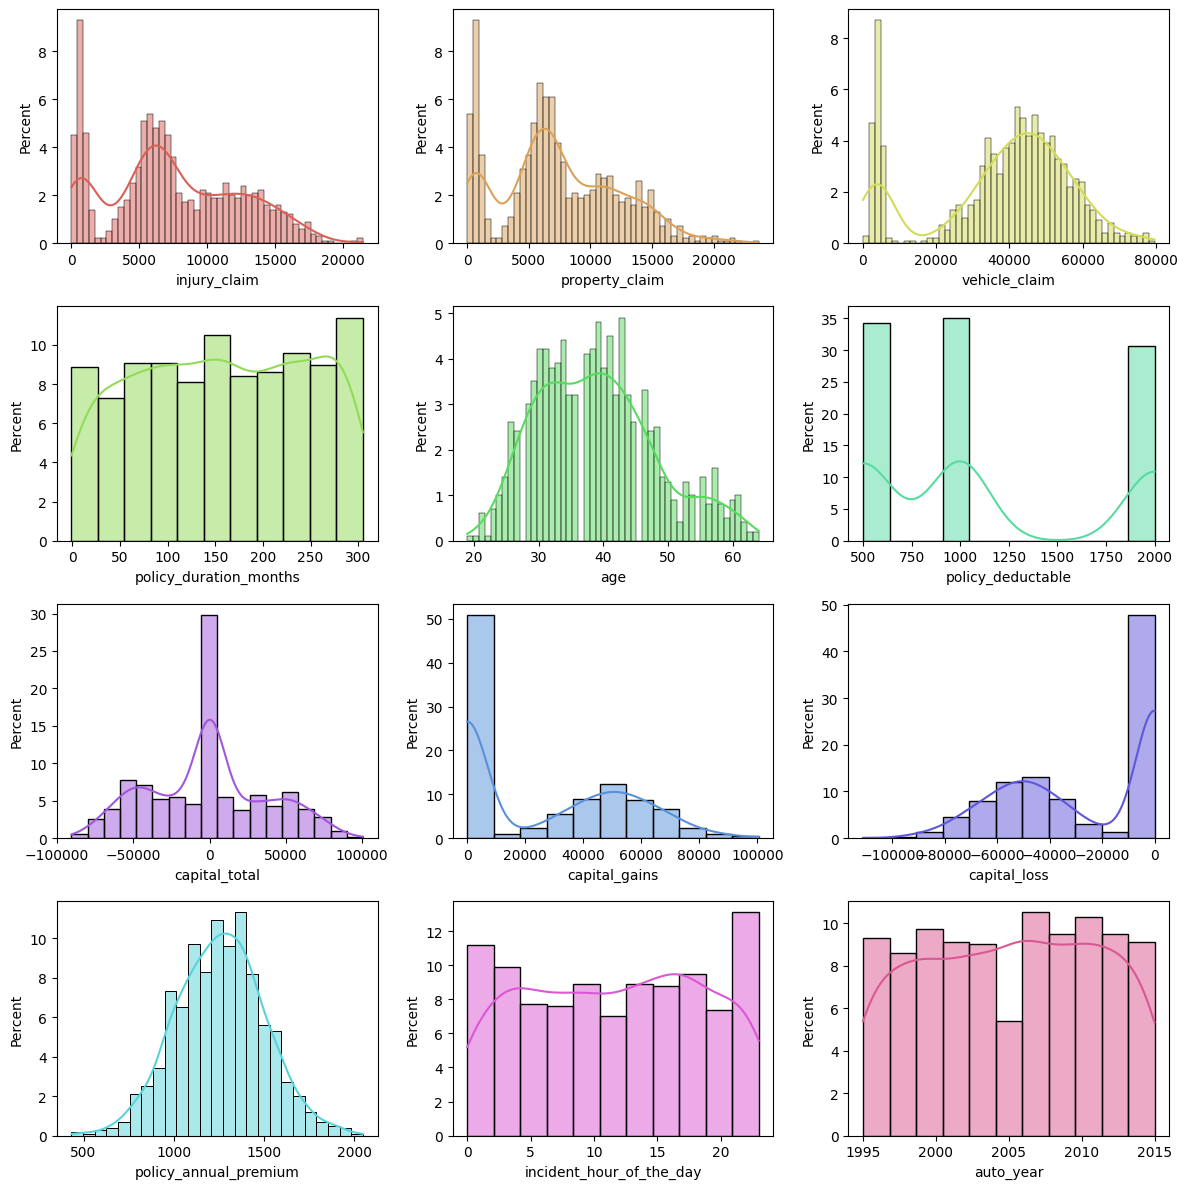

In [231]:
palette = sns.color_palette("hls", 12)
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
sns.histplot(x=df['injury_claim'], ax=axes[0, 0], bins=50, kde=True, color=palette[0], stat="percent")
sns.histplot(x=df['property_claim'], ax=axes[0, 1], bins=50, kde=True, color=palette[1], stat="percent")
sns.histplot(x=df['vehicle_claim'], ax=axes[0, 2], bins=50, kde=True, color=palette[2], stat="percent")
sns.histplot(x=df['policy_duration_months'], ax=axes[1, 0], kde=True, color=palette[3], stat="percent")
sns.histplot(x=df['age'], ax=axes[1, 1], bins=50, kde=True, color=palette[4], stat="percent")
sns.histplot(x=df['policy_deductable'], ax=axes[1, 2], kde=True, color=palette[5], stat="percent")
sns.histplot(x=df['policy_annual_premium'], ax=axes[3, 0], kde=True, color=palette[6], stat="percent")
sns.histplot(x=df['capital_gains'], ax=axes[2, 1], kde=True, color=palette[7], stat="percent")
sns.histplot(x=df['capital_loss'], ax=axes[2, 2], kde=True, color=palette[8], stat="percent")
sns.histplot(x=df['capital_total'], ax=axes[2, 0], kde=True, color=palette[9], stat="percent")
sns.histplot(x=df['incident_hour_of_the_day'], ax=axes[3, 1], kde=True, color=palette[10], stat="percent")
sns.histplot(x=df['auto_year'], ax=axes[3, 2], kde=True, color=palette[11], stat="percent")

plt.tight_layout()
plt.show()

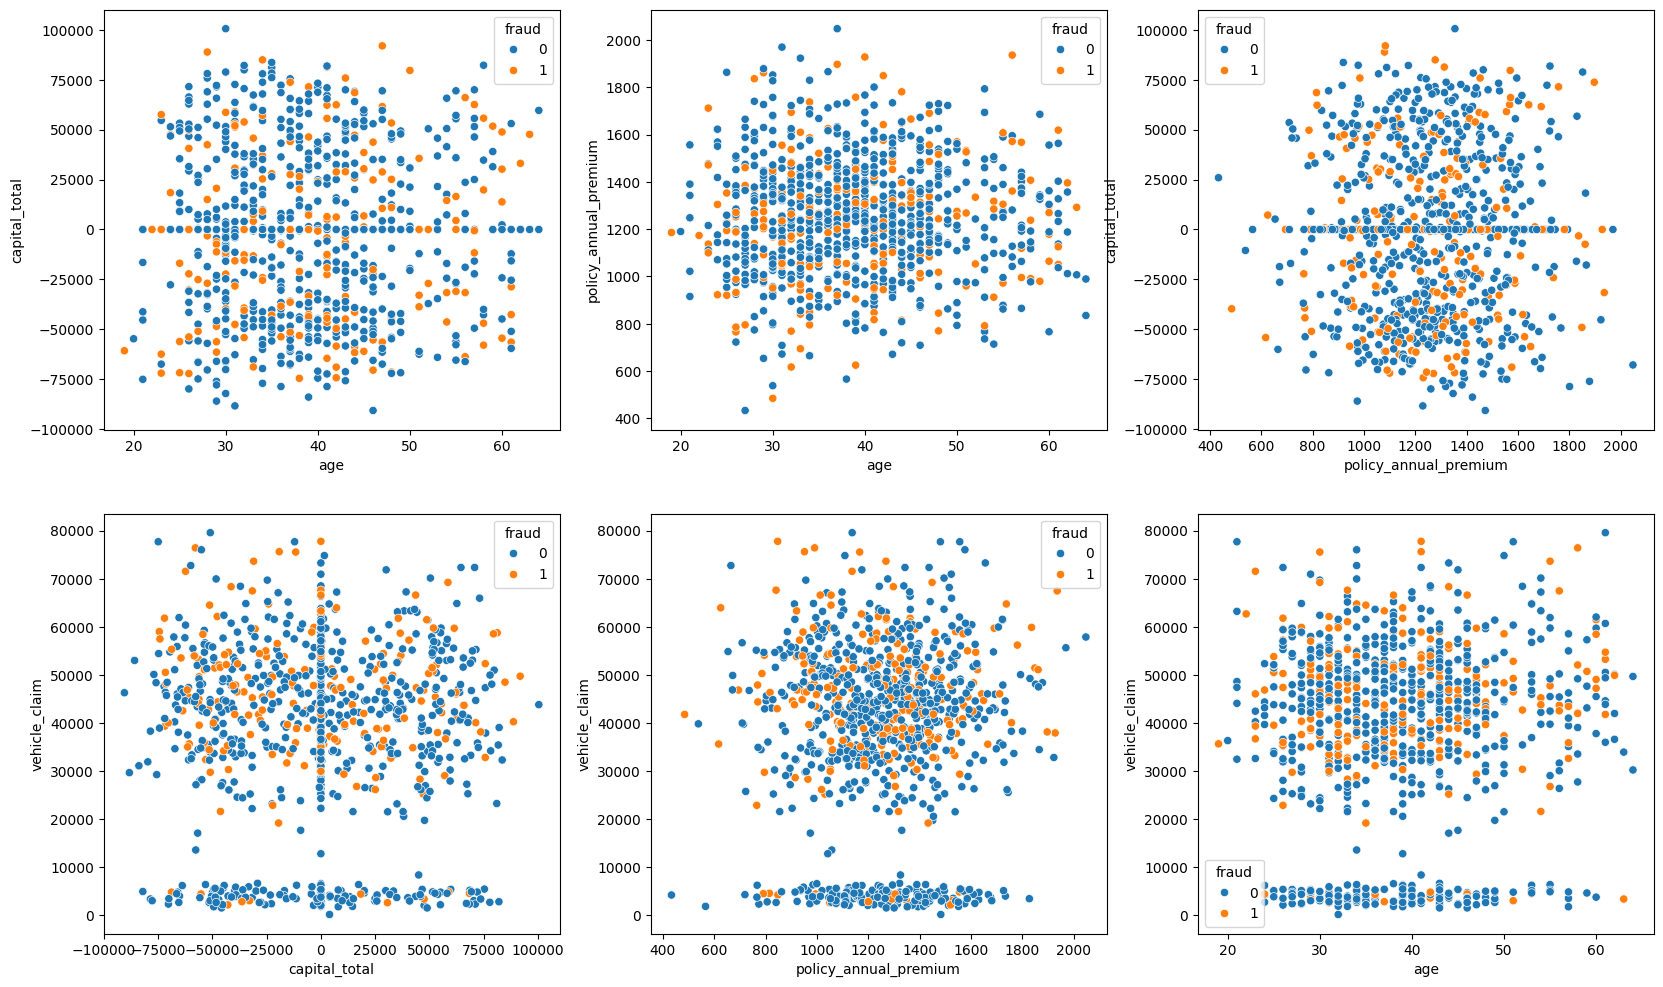

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
sns.scatterplot(x='age',y='capital_total', data=df, hue='fraud', ax=axes[0,0])
sns.scatterplot(x='age',y='policy_annual_premium', data=df, hue='fraud', ax=axes[0,1])
sns.scatterplot(x='age',y='vehicle_claim', data=df, hue='fraud' ,ax=axes[1,2])
sns.scatterplot(x='capital_total',y='vehicle_claim', data=df, hue='fraud' ,ax=axes[1,0])
sns.scatterplot(x='policy_annual_premium',y='vehicle_claim', data=df, hue='fraud' ,ax=axes[1,1])
sns.scatterplot(x='policy_annual_premium',y='capital_total', data=df, hue='fraud' ,ax=axes[0,2]);

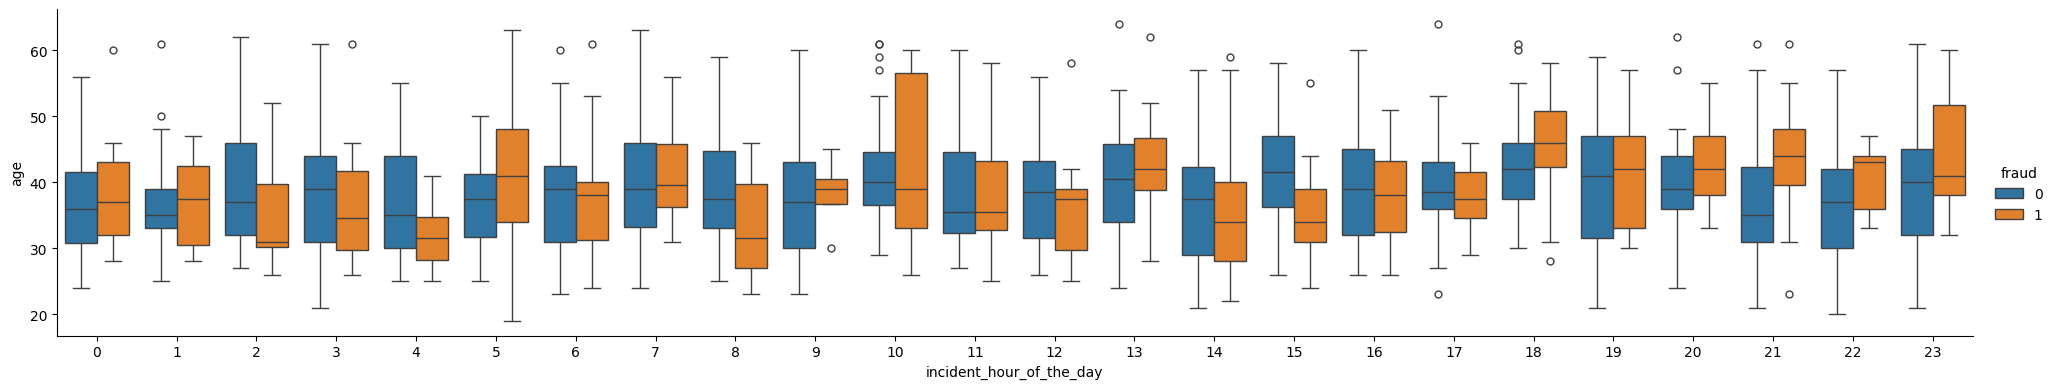

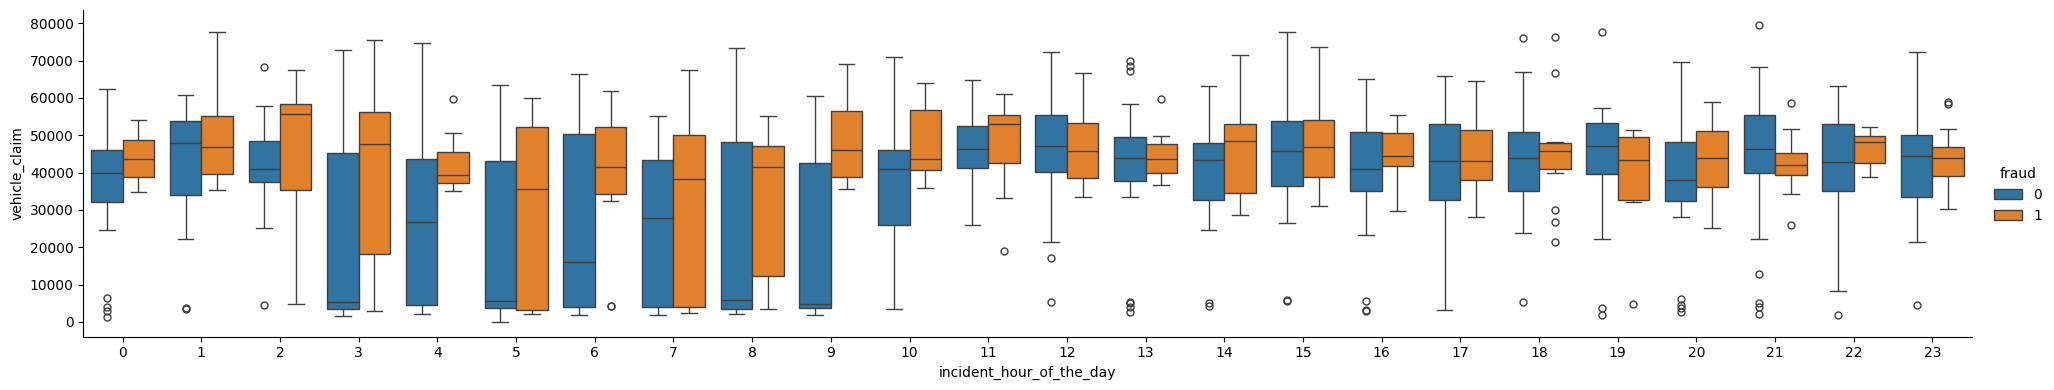

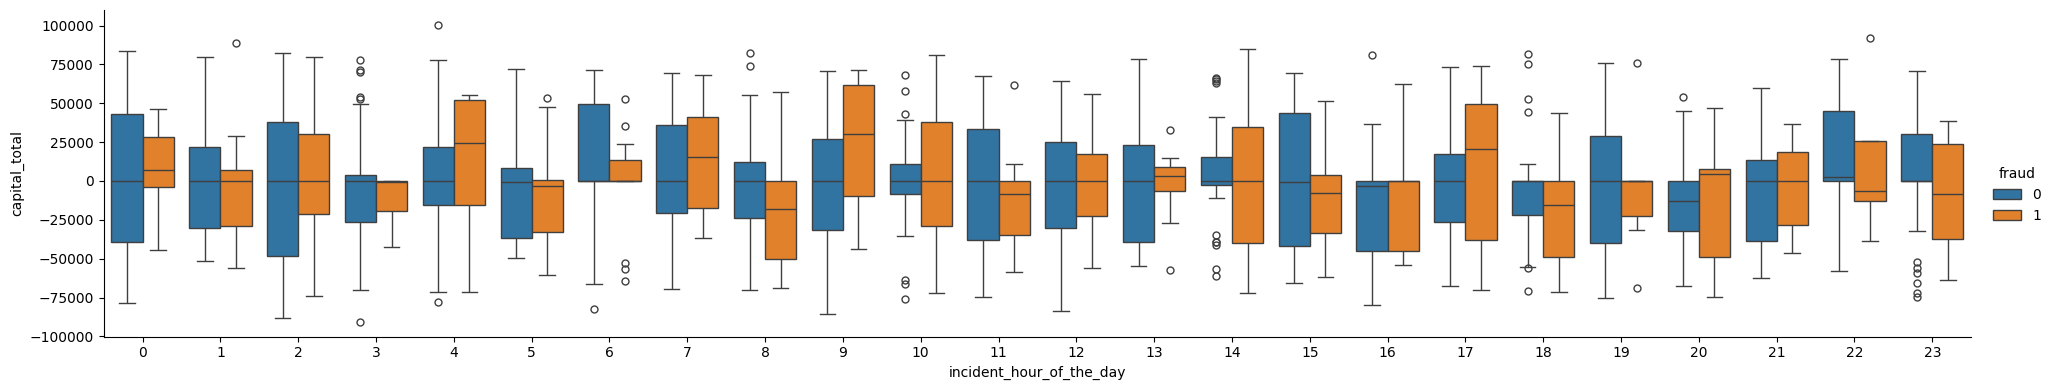

In [ ]:

sns.catplot(x='incident_hour_of_the_day',y='age', data=df,hue='fraud',kind='box',height=4, aspect=5)
sns.catplot(x='incident_hour_of_the_day',y='vehicle_claim', data=df, hue='fraud', kind='box',height=4, aspect=5)
sns.catplot(x='incident_hour_of_the_day',y='capital_total', data=df, hue='fraud',kind='box',height=4, aspect=5);

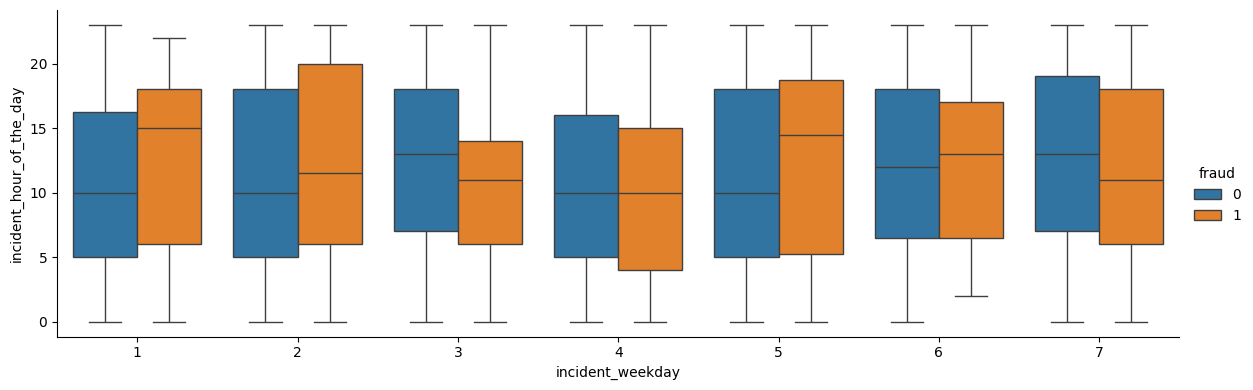

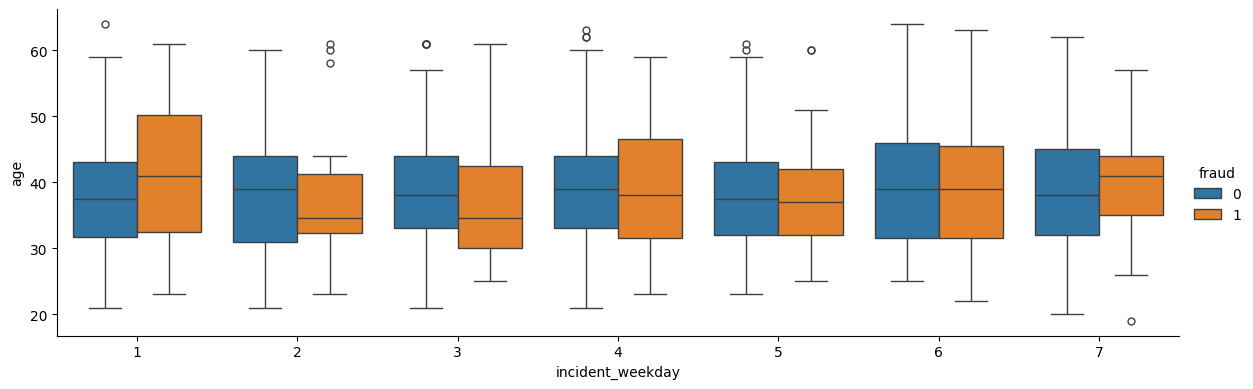

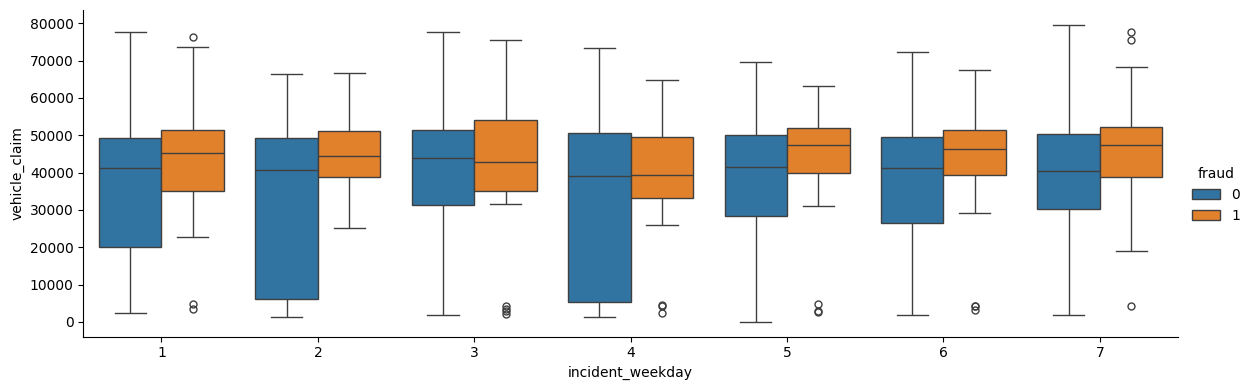

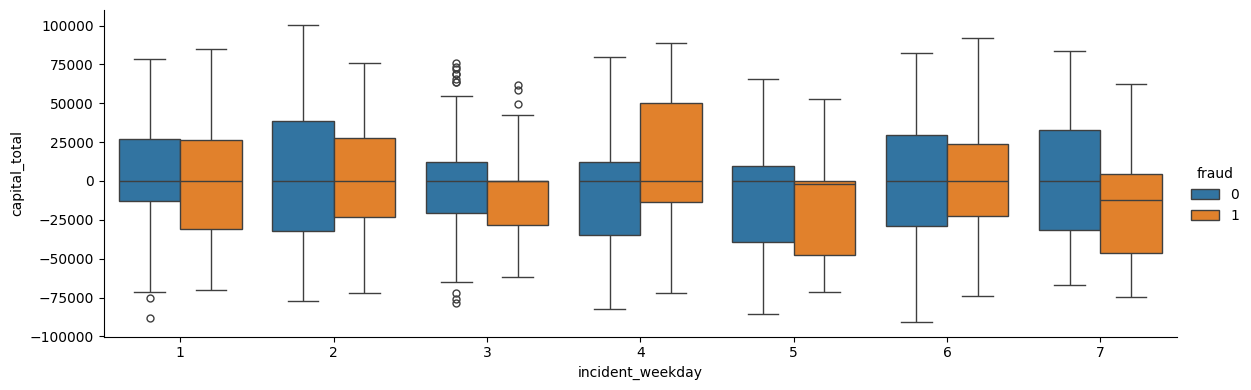

In [ ]:
sns.catplot(y='incident_hour_of_the_day',x='incident_weekday', data=df, hue='fraud',kind='box',height=4, aspect=3)
sns.catplot(x='incident_weekday',y='age', data=df,hue='fraud',kind='box',height=4, aspect=3)
sns.catplot(x='incident_weekday',y='vehicle_claim', data=df, hue='fraud', kind='box',height=4, aspect=3)
sns.catplot(x='incident_weekday',y='capital_total', data=df, hue='fraud',kind='box',height=4, aspect=3);

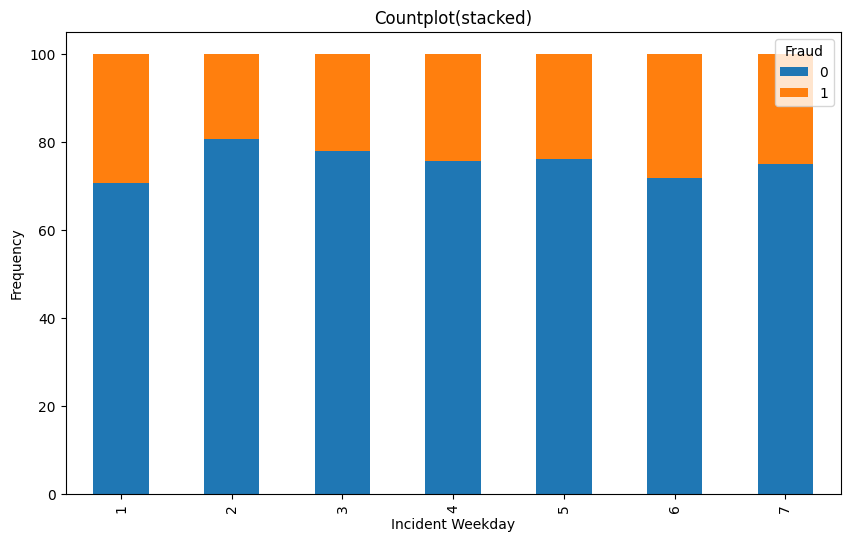

In [ ]:

data = df.groupby(['incident_weekday', 'fraud']).size().unstack().fillna(0)

data_percent = data.divide(data.sum(axis=1), axis=0) * 100

data_percent.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Incident Weekday')
plt.ylabel('Frequency')
plt.title('Countplot(stacked)')
plt.legend(title='Fraud')
plt.show()

In [ ]:
from scipy.stats import ttest_ind

group0 = df[df['fraud'] == 0]['age']
group1 = df[df['fraud'] == 1]['age']

t_stat, p_value = ttest_ind(group0, group1)

print('Result on feature: Age')
print("t-Statistik:", t_stat)
print("p-Wert:", p_value)

print('Result on feature: Policy_annual_premium')
group0 = df[df['fraud'] == 0]['policy_annual_premium']
group1 = df[df['fraud'] == 1]['policy_annual_premium']

t_stat, p_value = ttest_ind(group0, group1)

print("t-Statistik:", t_stat)
print("p-Wert:", p_value)

print('Result on feature: capital_total')
group0 = df[df['fraud'] == 0]['capital_total']
group1 = df[df['fraud'] == 1]['capital_total']

t_stat, p_value = ttest_ind(group0, group1)

print("t-Statistik:", t_stat)
print("p-Wert:", p_value)

Result on feature: Age
t-Statistik: -0.38365092414841734
p-Wert: 0.7013189051151347
Result on feature: Policy_annual_premium
t-Statistik: 0.4574753742411815
p-Wert: 0.6474289700892819
Result on feature: capital_total
t-Statistik: 0.7786053001898863
p-Wert: 0.43639681850510637


In [ ]:
# df.drop(["total_claim_amount",'policy_deductable'], axis=1, inplace=True)

# Analysis on categorical features

In [ ]:
col_qual = df.drop(col_quan,axis=1).columns
col_qual = col_qual.drop(["incident_date",'policy_bind_date',"incident_location"])

fraud,0,1
policy_state,,
IL,0.772,0.228
IN,0.745,0.255
OH,0.741,0.259


policy_state :  p_value: 0.9984893697781196 V_Cramer:  0.03174662579556386


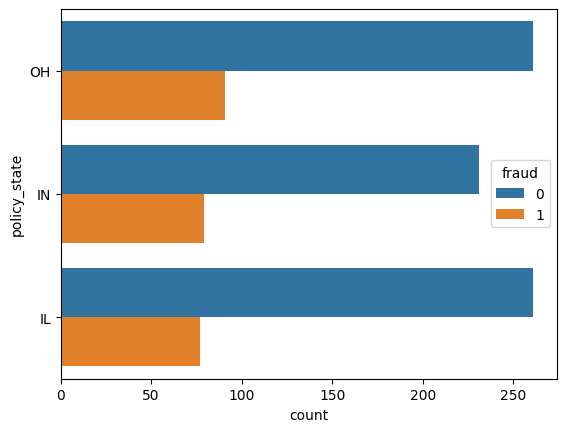

fraud,0,1
policy_csl,,
100/300,0.742,0.258
250/500,0.738,0.262
500/1000,0.783,0.217


policy_csl :  p_value: 0.9966038831386684 V_Cramer:  0.04762280095389609


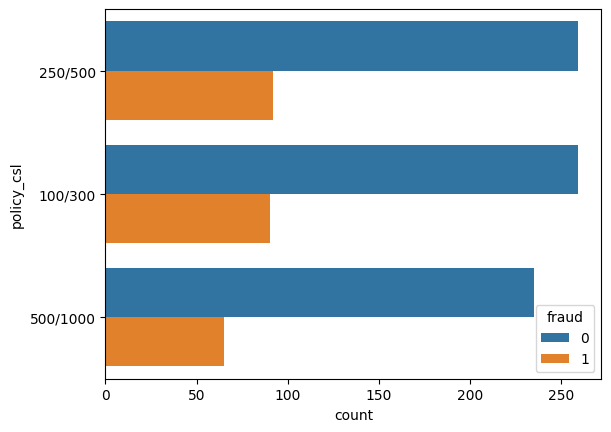

fraud,0,1
insured_education_level,,
Associate,0.766,0.234
College,0.738,0.262
High School,0.775,0.225
JD,0.739,0.261
MD,0.736,0.264
Masters,0.776,0.224
PhD,0.736,0.264


insured_education_level :  p_value: 0.999999966963553 V_Cramer:  0.0408451363808503


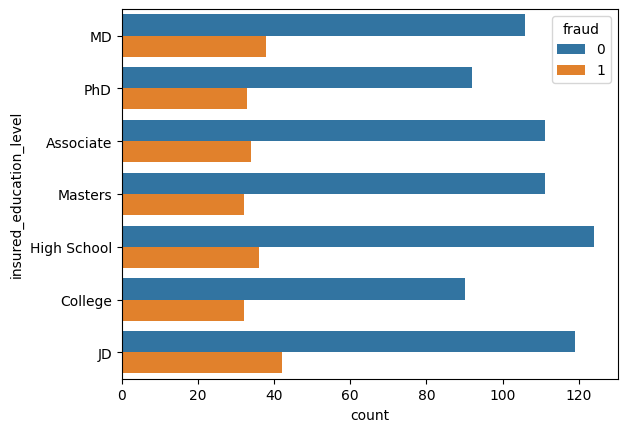

fraud,0,1
insured_occupation,,
adm-clerical,0.831,0.169
armed-forces,0.754,0.246
craft-repair,0.703,0.297
exec-managerial,0.632,0.368
farming-fishing,0.698,0.302
handlers-cleaners,0.796,0.204
machine-op-inspct,0.763,0.237
other-service,0.831,0.169
priv-house-serv,0.831,0.169


insured_occupation :  p_value: 0.9999999993510679 V_Cramer:  0.13366478292276512


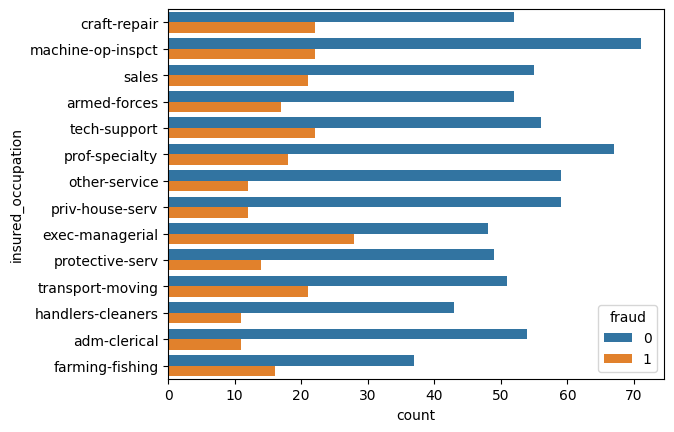

fraud,0,1
insured_hobbies,,
base-jumping,0.735,0.265
basketball,0.824,0.176
board-games,0.708,0.292
bungie-jumping,0.839,0.161
camping,0.909,0.091
chess,0.174,0.826
cross-fit,0.257,0.743
dancing,0.884,0.116
exercise,0.807,0.193


insured_hobbies :  p_value: 0.9999478176634603 V_Cramer:  0.42726813358917637


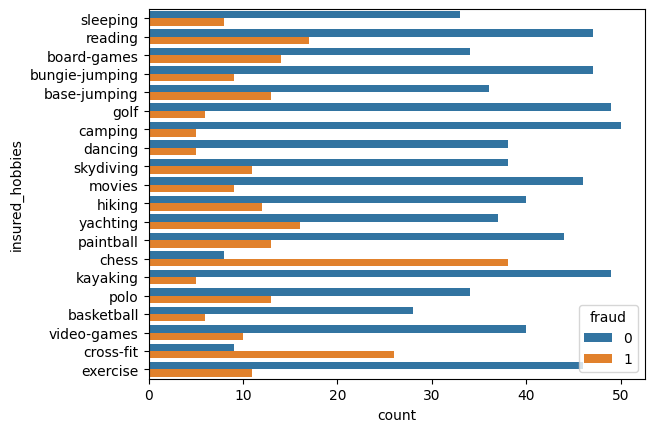

fraud,0,1
insured_relationship,,
husband,0.794,0.206
not-in-family,0.741,0.259
other-relative,0.706,0.294
own-child,0.787,0.213
unmarried,0.759,0.241
wife,0.729,0.271


insured_relationship :  p_value: 0.9999910926943366 V_Cramer:  0.07188947796729575


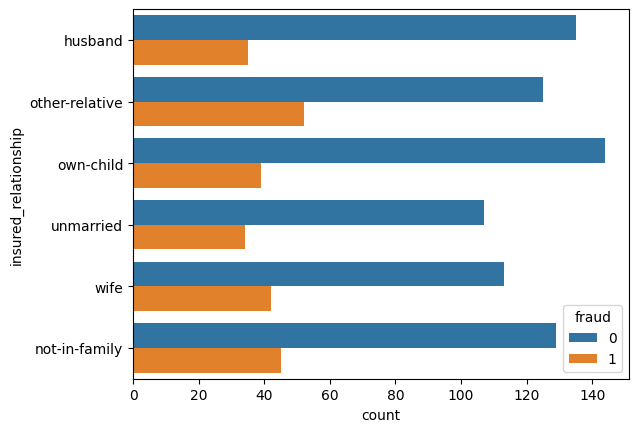

fraud,0,1
incident_type,,
Multi-vehicle Collision,0.728,0.272
Parked Car,0.905,0.095
Single Vehicle Collision,0.710,0.290
Vehicle Theft,0.915,0.085


incident_type :  p_value: 0.9704052771632713 V_Cramer:  0.24636103605698642


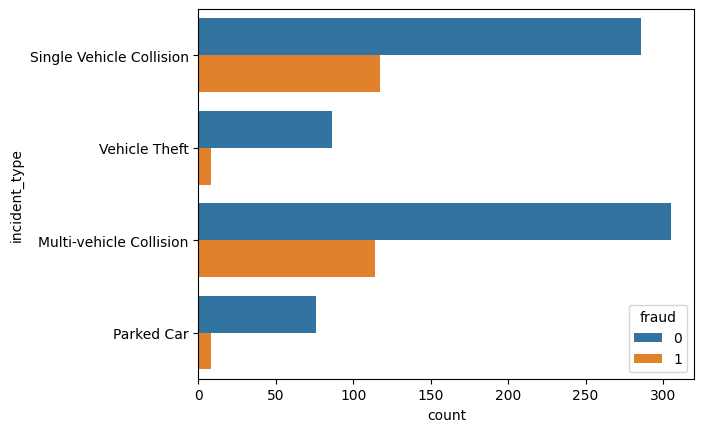

fraud,0,1
collision_type,,
?,0.910,0.090
Front Collision,0.724,0.276
Rear Collision,0.688,0.312
Side Collision,0.746,0.254


collision_type :  p_value: 0.9834931231314934 V_Cramer:  0.20117948242502517


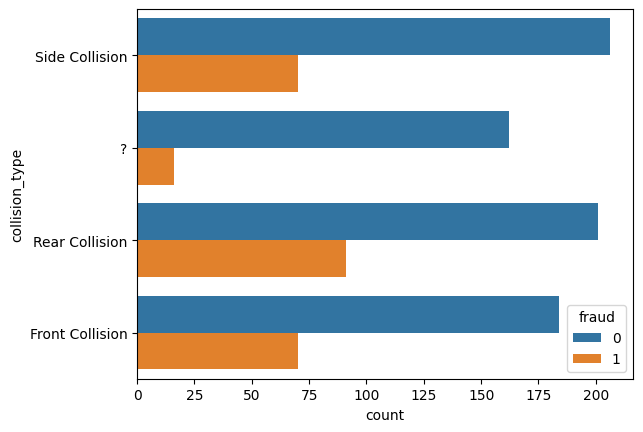

fraud,0,1
incident_severity,,
Major Damage,0.395,0.605
Minor Damage,0.893,0.107
Total Loss,0.871,0.129
Trivial Damage,0.933,0.067


incident_severity :  p_value: 0.7775078430731575 V_Cramer:  0.5239759663410746


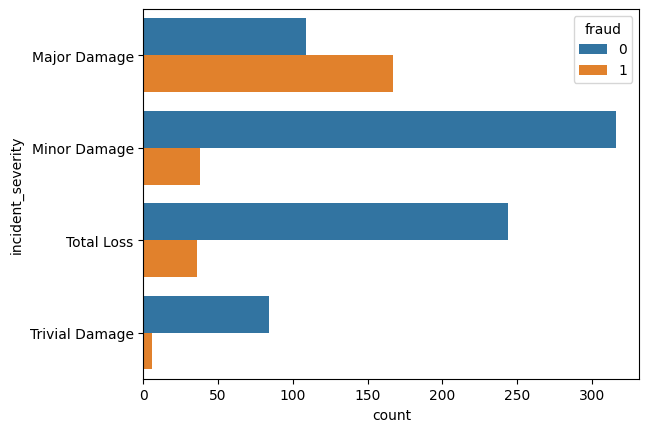

fraud,0,1
authorities_contacted,,
Ambulance,0.709,0.291
Fire,0.731,0.269
Other,0.682,0.318
Police,0.791,0.209


authorities_contacted :  p_value: 0.9984408490422351 V_Cramer:  0.0904509315942737


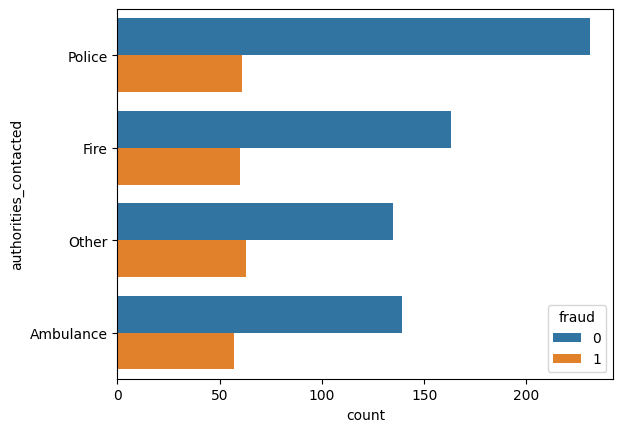

fraud,0,1
incident_state,,
NC,0.691,0.309
NY,0.779,0.221
OH,0.565,0.435
PA,0.733,0.267
SC,0.706,0.294
VA,0.773,0.227
WV,0.820,0.180


incident_state :  p_value: 0.9998292475286108 V_Cramer:  0.1719175033791722


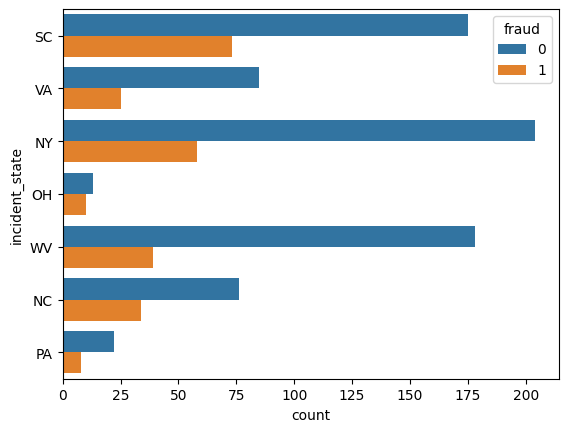

fraud,0,1
incident_city,,
Arlington,0.711,0.289
Columbus,0.738,0.262
Hillsdale,0.752,0.248
Northbend,0.766,0.234
Northbrook,0.779,0.221
Riverwood,0.776,0.224
Springfield,0.758,0.242


incident_city :  p_value: 0.9999998735741239 V_Cramer:  0.05110459653517462


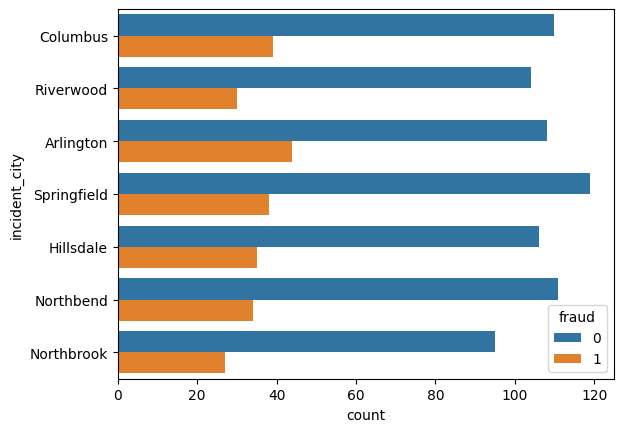

fraud,0,1
property_damage,,
?,0.714,0.286
NO,0.805,0.195
YES,0.742,0.258


property_damage :  p_value: 0.9884060265553408 V_Cramer:  0.08817296487562451


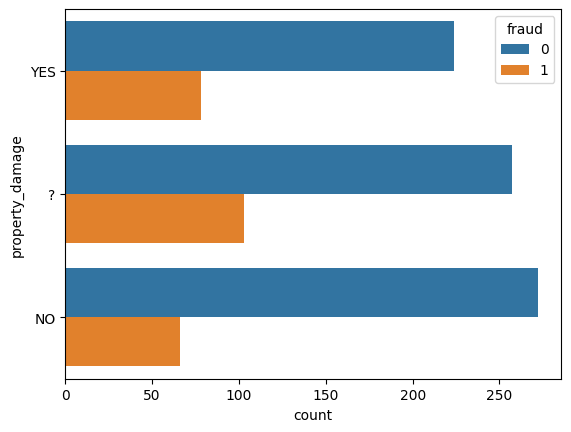

fraud,0,1
police_report_available,,
?,0.741,0.259
NO,0.749,0.251
YES,0.771,0.229


police_report_available :  p_value: 0.998703044268707 V_Cramer:  0.029414253985508745


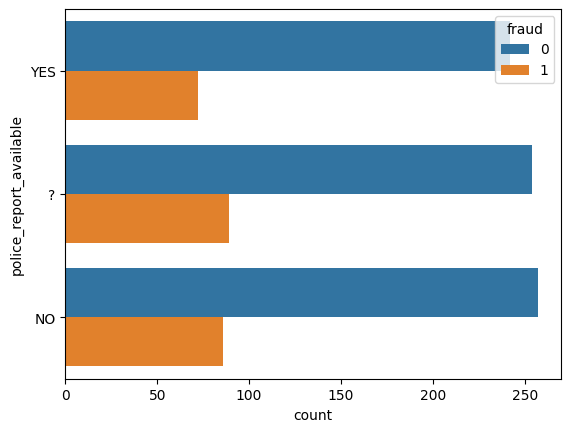

fraud,0,1
total_claim_amount,,
100,1.0,0.0
1920,1.0,0.0
2160,1.0,0.0
2250,1.0,0.0
2400,1.0,0.0
...,...,...
107900,0.0,1.0
108030,1.0,0.0
108480,1.0,0.0


total_claim_amount :  p_value: 0.9937603915337562 V_Cramer:  0.9356554388724697


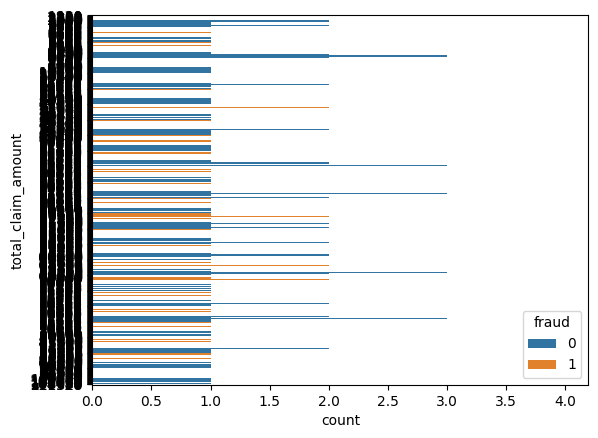

fraud,0,1
auto_make,,
Accura,0.809,0.191
Audi,0.696,0.304
BMW,0.722,0.278
Chevrolet,0.724,0.276
Dodge,0.750,0.250
Ford,0.694,0.306
Honda,0.745,0.255
Jeep,0.836,0.164
Mercedes,0.662,0.338


auto_make :  p_value: 0.999999999855908 V_Cramer:  0.1188464376899435


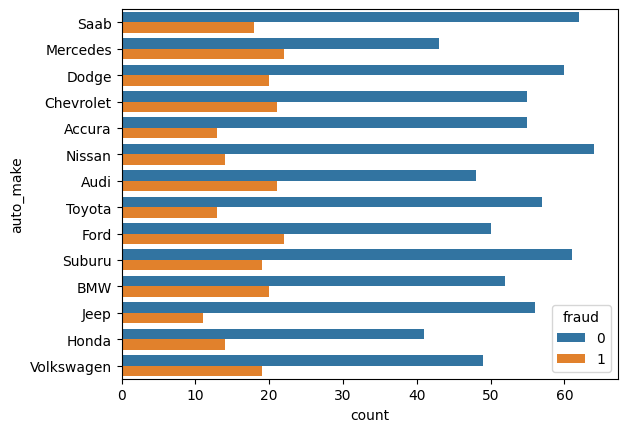

fraud,0,1
auto_model,,
3 Series,0.944,0.056
92x,0.714,0.286
93,0.800,0.200
95,0.815,0.185
A3,0.730,0.270
A5,0.656,0.344
Accord,0.769,0.231
C300,0.611,0.389
CRV,0.850,0.150


auto_model :  p_value: 1.0 V_Cramer:  0.22575346490396925


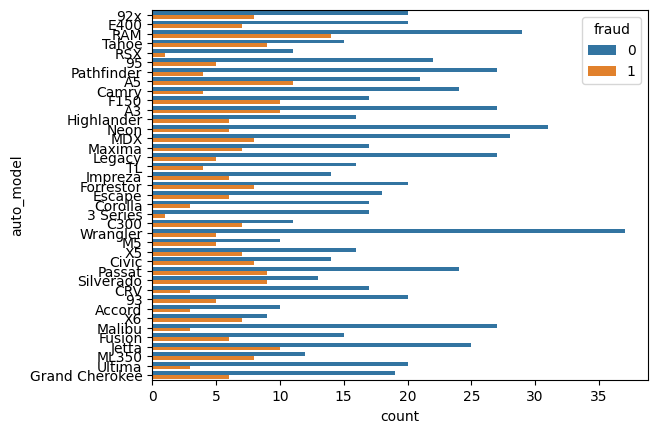

In [ ]:
for col in col_qual:
    display(np.round(pd.crosstab(df[col], df["fraud"], normalize='index'),3))
    cross_tmp = pd.crosstab(df[col], df["fraud"], normalize="index")
    stat, p,  = chi2_contingency(cross_tmp)[:2]
    V_Cramer = np.sqrt(stat/cross_tmp.values.sum())
    print(col,": ",'p_value:', p,'V_Cramer: ', V_Cramer)


    sns.countplot(y=col, data=df, hue= 'fraud', )
    plt.show()
    

authorities_contacted,Ambulance,Fire,Other,Police,NaN
policy_state,,,,,
IL,0.316,0.323,0.369,0.353,0.308
IN,0.357,0.309,0.268,0.301,0.330
OH,0.327,0.368,0.364,0.346,0.363


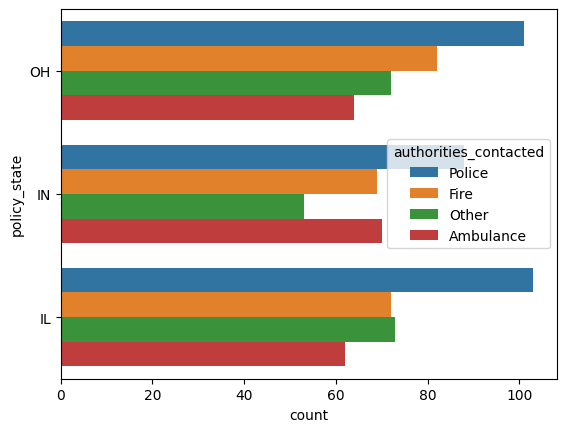

authorities_contacted,Ambulance,Fire,Other,Police,NaN
policy_csl,,,,,
100/300,0.439,0.345,0.333,0.332,0.253
250/500,0.306,0.350,0.374,0.356,0.385
500/1000,0.255,0.305,0.293,0.312,0.363


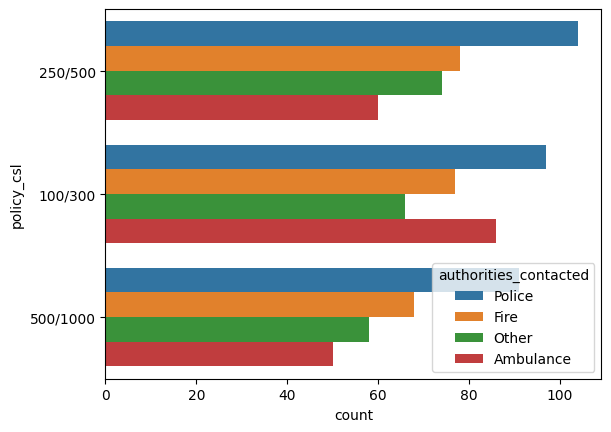

authorities_contacted,Ambulance,Fire,Other,Police,NaN
insured_education_level,,,,,
Associate,0.148,0.130,0.136,0.151,0.176
College,0.128,0.130,0.116,0.120,0.110
High School,0.153,0.152,0.157,0.175,0.154
JD,0.158,0.139,0.167,0.171,0.176
MD,0.163,0.139,0.172,0.120,0.132
Masters,0.163,0.157,0.101,0.147,0.143
PhD,0.087,0.152,0.152,0.116,0.110


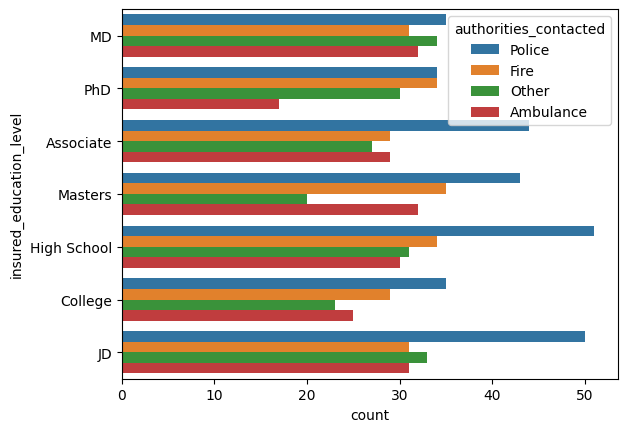

authorities_contacted,Ambulance,Fire,Other,Police,NaN
insured_occupation,,,,,
adm-clerical,0.056,0.045,0.061,0.072,0.121
armed-forces,0.066,0.063,0.071,0.062,0.110
craft-repair,0.071,0.081,0.096,0.065,0.044
exec-managerial,0.077,0.063,0.096,0.068,0.088
farming-fishing,0.071,0.045,0.051,0.048,0.055
handlers-cleaners,0.036,0.058,0.071,0.065,0.011
machine-op-inspct,0.117,0.090,0.081,0.096,0.066
other-service,0.092,0.063,0.056,0.062,0.110
priv-house-serv,0.061,0.081,0.071,0.075,0.055


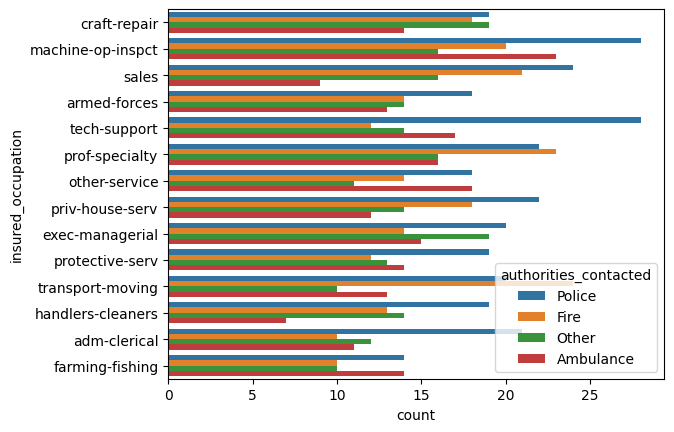

authorities_contacted,Ambulance,Fire,Other,Police,NaN
insured_hobbies,,,,,
base-jumping,0.031,0.045,0.071,0.045,0.066
basketball,0.020,0.036,0.040,0.038,0.033
board-games,0.031,0.049,0.066,0.045,0.055
bungie-jumping,0.061,0.045,0.056,0.065,0.044
camping,0.041,0.049,0.081,0.051,0.055
chess,0.082,0.036,0.040,0.038,0.033
cross-fit,0.051,0.031,0.040,0.031,0.011
dancing,0.046,0.058,0.020,0.048,0.033
exercise,0.056,0.040,0.066,0.072,0.033


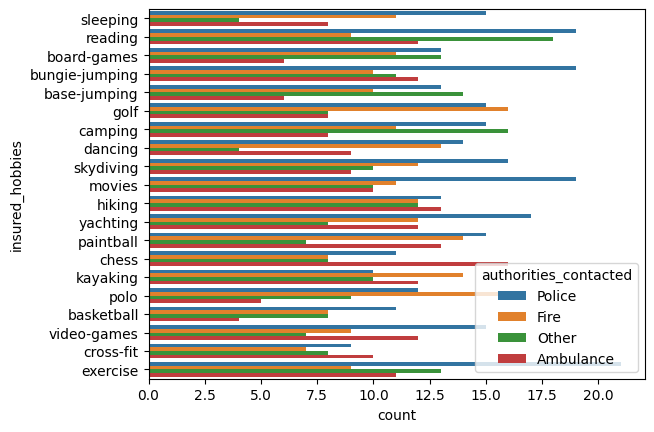

authorities_contacted,Ambulance,Fire,Other,Police,NaN
insured_relationship,,,,,
husband,0.199,0.135,0.187,0.171,0.154
not-in-family,0.184,0.184,0.182,0.147,0.198
other-relative,0.189,0.130,0.187,0.209,0.143
own-child,0.194,0.161,0.172,0.195,0.198
unmarried,0.112,0.188,0.116,0.144,0.132
wife,0.122,0.202,0.157,0.134,0.176


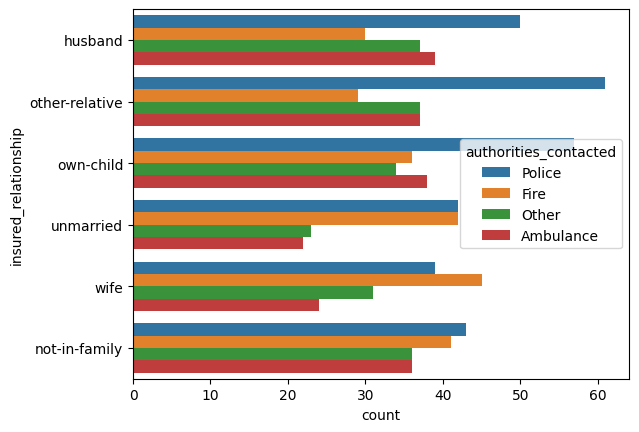

authorities_contacted,Ambulance,Fire,Other,Police,NaN
incident_type,,,,,
Multi-vehicle Collision,0.51,0.498,0.505,0.370,0.000
Parked Car,0.00,0.000,0.000,0.116,0.549
Single Vehicle Collision,0.49,0.502,0.495,0.332,0.000
Vehicle Theft,0.00,0.000,0.000,0.182,0.451


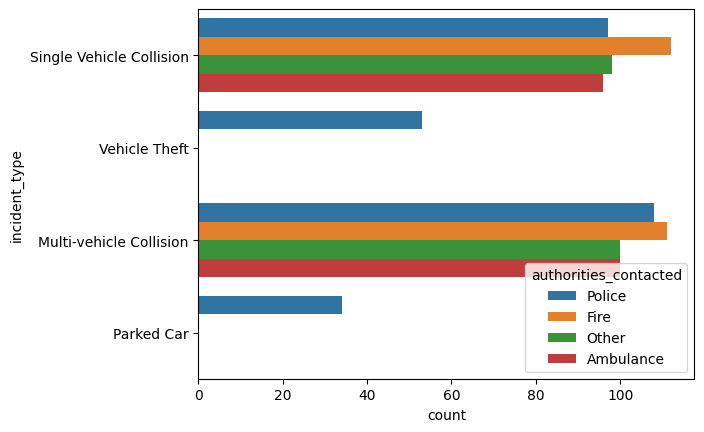

authorities_contacted,Ambulance,Fire,Other,Police,NaN
collision_type,,,,,
?,0.000,0.000,0.000,0.298,1.0
Front Collision,0.321,0.354,0.298,0.182,0.0
Rear Collision,0.378,0.332,0.333,0.267,0.0
Side Collision,0.301,0.314,0.369,0.253,0.0


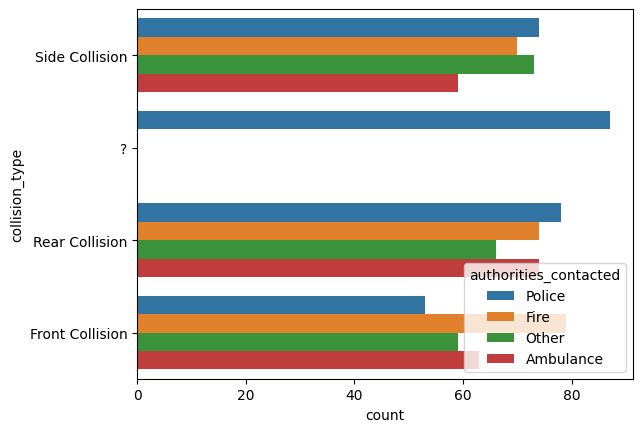

authorities_contacted,Ambulance,Fire,Other,Police,NaN
incident_severity,,,,,
Major Damage,0.357,0.368,0.333,0.199,0.000
Minor Damage,0.316,0.341,0.278,0.380,0.549
Total Loss,0.327,0.291,0.389,0.253,0.000
Trivial Damage,0.000,0.000,0.000,0.168,0.451


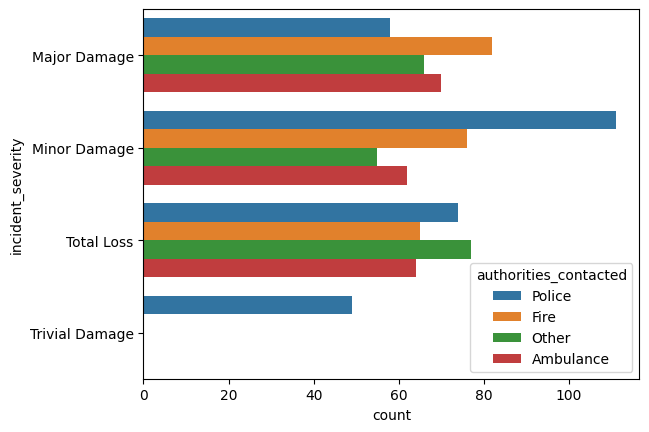

authorities_contacted,Ambulance,Fire,Other,Police,NaN
authorities_contacted,,,,,
Ambulance,1.0,0.0,0.0,0.0,0.0
Fire,0.0,1.0,0.0,0.0,0.0
Other,0.0,0.0,1.0,0.0,0.0
Police,0.0,0.0,0.0,1.0,0.0
NaN,0.0,0.0,0.0,0.0,1.0


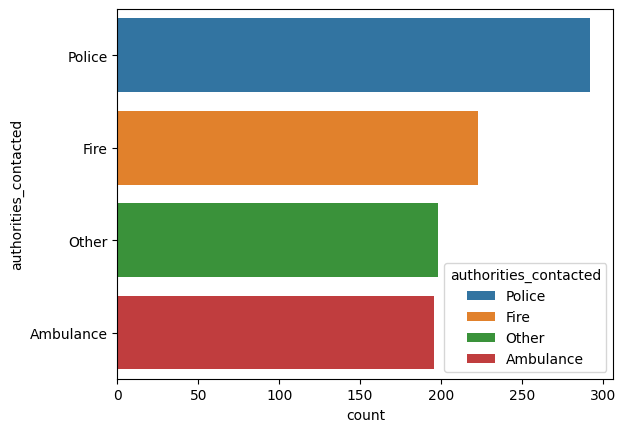

authorities_contacted,Ambulance,Fire,Other,Police,NaN
incident_state,,,,,
NC,0.133,0.094,0.091,0.110,0.143
NY,0.265,0.278,0.298,0.250,0.176
OH,0.026,0.018,0.035,0.014,0.033
PA,0.031,0.036,0.025,0.034,0.011
SC,0.204,0.291,0.258,0.236,0.253
VA,0.102,0.117,0.086,0.113,0.154
WV,0.240,0.166,0.207,0.243,0.231


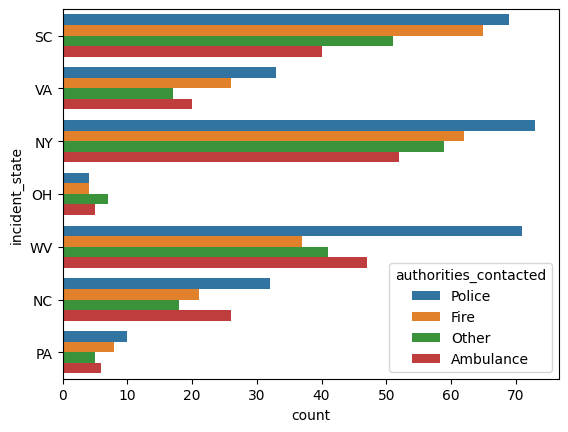

authorities_contacted,Ambulance,Fire,Other,Police,NaN
incident_city,,,,,
Arlington,0.148,0.112,0.131,0.168,0.253
Columbus,0.153,0.161,0.217,0.110,0.088
Hillsdale,0.133,0.161,0.136,0.134,0.143
Northbend,0.148,0.148,0.106,0.171,0.132
Northbrook,0.107,0.143,0.101,0.134,0.110
Riverwood,0.133,0.152,0.131,0.120,0.143
Springfield,0.179,0.121,0.177,0.164,0.132


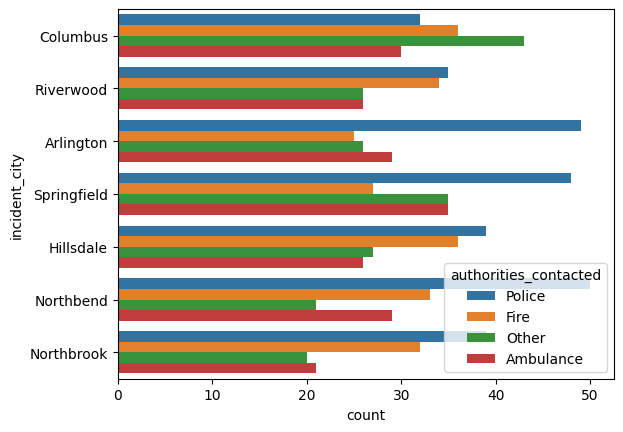

authorities_contacted,Ambulance,Fire,Other,Police,NaN
property_damage,,,,,
?,0.352,0.350,0.379,0.366,0.341
NO,0.332,0.354,0.323,0.329,0.374
YES,0.316,0.296,0.298,0.305,0.286


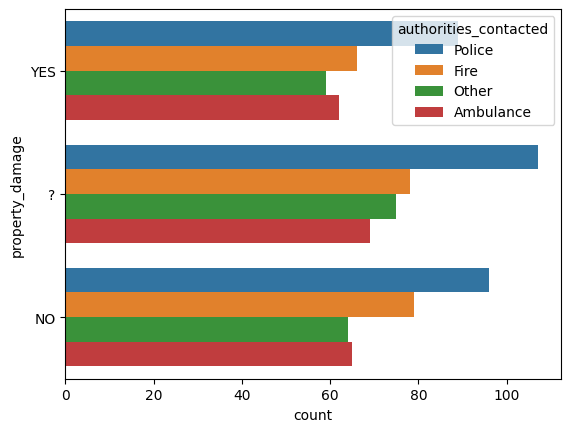

authorities_contacted,Ambulance,Fire,Other,Police,NaN
police_report_available,,,,,
?,0.352,0.345,0.369,0.332,0.297
NO,0.378,0.345,0.283,0.342,0.396
YES,0.270,0.309,0.348,0.325,0.308


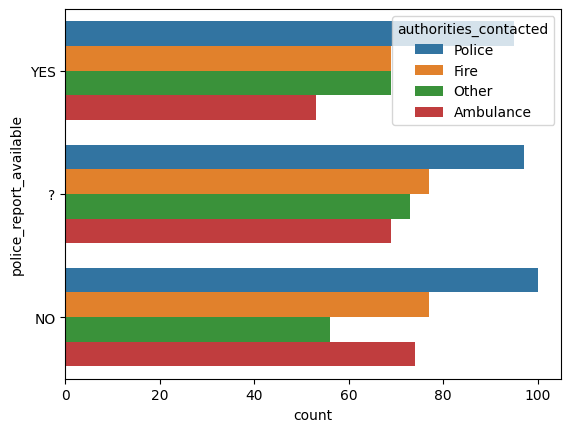

authorities_contacted,Ambulance,Fire,Other,Police,NaN
total_claim_amount,,,,,
100,0.0,0.000,0.000,0.003,0.000
1920,0.0,0.000,0.000,0.000,0.011
2160,0.0,0.000,0.000,0.003,0.000
2250,0.0,0.000,0.000,0.000,0.011
2400,0.0,0.000,0.000,0.000,0.011
...,...,...,...,...,...
107900,0.0,0.004,0.000,0.000,0.000
108030,0.0,0.000,0.005,0.000,0.000
108480,0.0,0.004,0.000,0.000,0.000


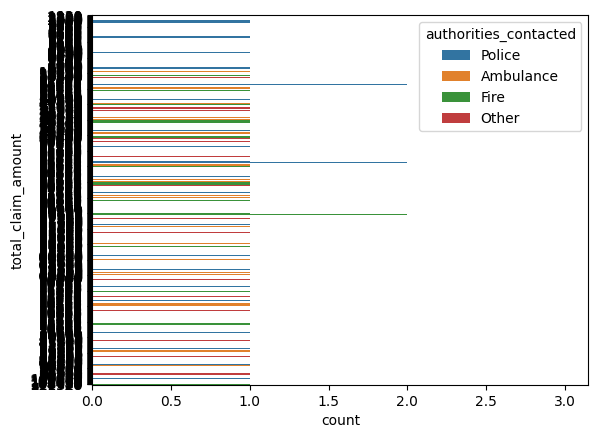

authorities_contacted,Ambulance,Fire,Other,Police,NaN
auto_make,,,,,
Accura,0.056,0.054,0.106,0.065,0.055
Audi,0.082,0.063,0.066,0.068,0.066
BMW,0.051,0.076,0.081,0.082,0.055
Chevrolet,0.046,0.103,0.061,0.075,0.110
Dodge,0.102,0.054,0.081,0.082,0.088
Ford,0.087,0.085,0.066,0.062,0.055
Honda,0.046,0.081,0.051,0.045,0.055
Jeep,0.077,0.045,0.045,0.096,0.055
Mercedes,0.046,0.076,0.076,0.065,0.055


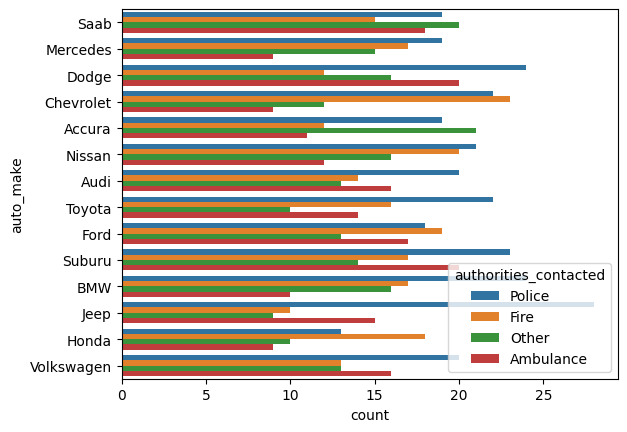

authorities_contacted,Ambulance,Fire,Other,Police,NaN
auto_model,,,,,
3 Series,0.010,0.009,0.020,0.034,0.000
92x,0.026,0.027,0.040,0.017,0.044
93,0.046,0.013,0.030,0.017,0.022
95,0.020,0.027,0.030,0.031,0.022
A3,0.041,0.040,0.035,0.031,0.044
A5,0.041,0.022,0.030,0.038,0.022
Accord,0.015,0.013,0.015,0.014,0.000
C300,0.010,0.027,0.025,0.017,0.000
CRV,0.015,0.031,0.015,0.021,0.011


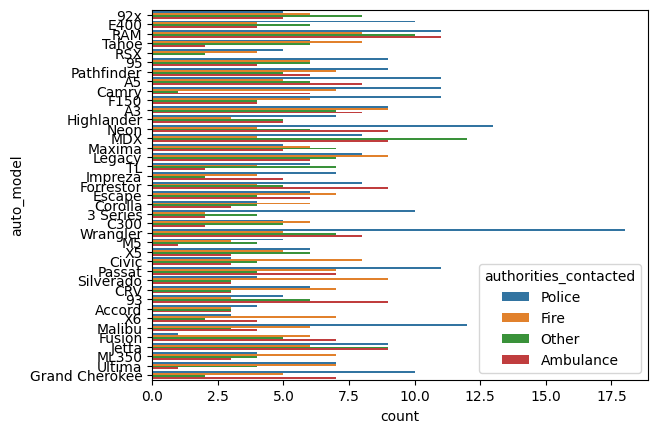

In [ ]:
for col in col_qual:
    display(np.round(pd.crosstab(df[col], df['authorities_contacted'], normalize=1,dropna=False),3))
    sns.countplot(y=col, data=df, hue= 'authorities_contacted', )
    plt.show()

In [ ]:
print(df['auto_model'].value_counts(normalize=True,dropna=False).head(20).sum())
df['auto_model'].nunique()
100/39

0.6270000000000001


2.5641025641025643